In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data preprocessed
df = pd.read_csv('spotify_preprocessed.csv')

# Fitur dan target
feature_cols = ['artist_popularity', 'artist_followers', 'track_duration_min',
                'track_number', 'album_total_tracks', 'explicit', 
                'release_year', 'album_type_encoded']

X = df[feature_cols]
y = df['track_popularity']

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data siap untuk modeling!")
print(f"Training set : {X_train.shape[0]} baris")
print(f"Testing set  : {X_test.shape[0]} baris")
print(f"Jumlah fitur : {X_train.shape[1]}")

✅ Data siap untuk modeling!
Training set : 6865 baris
Testing set  : 1717 baris
Jumlah fitur : 8


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data preprocessed
df = pd.read_csv('spotify_preprocessed.csv')

# Fitur dan target
feature_cols = ['artist_popularity', 'artist_followers', 'track_duration_min',
                'track_number', 'album_total_tracks', 'explicit', 
                'release_year', 'album_type_encoded']

X = df[feature_cols]
y = df['track_popularity']

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Normalisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data siap untuk modeling!")
print(f"Training set : {X_train.shape[0]} baris")
print(f"Testing set  : {X_test.shape[0]} baris")
print(f"Jumlah fitur : {X_train.shape[1]}")

✅ Data siap untuk modeling!
Training set : 6865 baris
Testing set  : 1717 baris
Jumlah fitur : 8


In [6]:
from sklearn.linear_model import LinearRegression
import joblib

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluasi
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== LINEAR REGRESSION ===")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

# Simpan model
joblib.dump(lr_model, 'model_linear_regression.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n✅ Model Linear Regression berhasil disimpan!")

=== LINEAR REGRESSION ===
MAE  : 15.7135
RMSE : 20.6721
R²   : 0.2810

✅ Model Linear Regression berhasil disimpan!


In [7]:
from tensorflow import keras
from keras import layers

# Bangun model ANN
ann_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=0
)

# Evaluasi
y_pred_ann = ann_model.predict(X_test_scaled).flatten()
mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("=== ARTIFICIAL NEURAL NETWORK ===")
print(f"MAE  : {mae_ann:.4f}")
print(f"RMSE : {rmse_ann:.4f}")
print(f"R²   : {r2_ann:.4f}")

# Simpan model
ann_model.save('model_ann.h5')
print("\n✅ Model ANN berhasil disimpan!")

54/54 [==============================] - 0s 648us/step
=== ARTIFICIAL NEURAL NETWORK ===
MAE  : 15.3639
RMSE : 20.2005
R²   : 0.3134

✅ Model ANN berhasil disimpan!


In [8]:
from tensorflow import keras
from keras import layers

# Bangun model ANN
ann_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=0
)

# Evaluasi
y_pred_ann = ann_model.predict(X_test_scaled).flatten()
mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("=== ARTIFICIAL NEURAL NETWORK ===")
print(f"MAE  : {mae_ann:.4f}")
print(f"RMSE : {rmse_ann:.4f}")
print(f"R²   : {r2_ann:.4f}")

# Simpan model
ann_model.save('model_ann.h5')
print("\n✅ Model ANN berhasil disimpan!")

54/54 [==============================] - 0s 582us/step
=== ARTIFICIAL NEURAL NETWORK ===
MAE  : 14.8261
RMSE : 20.0493
R²   : 0.3237

✅ Model ANN berhasil disimpan!


In [9]:
from tensorflow import keras
from keras import layers

# Bangun model ANN
ann_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=0
)

# Evaluasi
y_pred_ann = ann_model.predict(X_test_scaled).flatten()
mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("=== ARTIFICIAL NEURAL NETWORK ===")
print(f"MAE  : {mae_ann:.4f}")
print(f"RMSE : {rmse_ann:.4f}")
print(f"R²   : {r2_ann:.4f}")

# Simpan model
ann_model.save('model_ann.h5')
print("\n✅ Model ANN berhasil disimpan!")

54/54 [==============================] - 0s 1ms/step
=== ARTIFICIAL NEURAL NETWORK ===
MAE  : 14.9171
RMSE : 20.1789
R²   : 0.3149

✅ Model ANN berhasil disimpan!


In [10]:
# RNN/LSTM - Prediksi tren popularity per tahun
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Buat data time series per tahun
yearly_data = df.groupby('release_year')['track_popularity'].mean().reset_index()
yearly_data = yearly_data.sort_values('release_year')

# Normalisasi
scaler_lstm = MinMaxScaler()
popularity_scaled = scaler_lstm.fit_transform(yearly_data[['track_popularity']])

# Buat sequences
def create_sequences(data, seq_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(popularity_scaled)
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# Bangun model LSTM
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], 1)),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Train
history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=8,
    verbose=0
)

# Evaluasi
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm_inv = scaler_lstm.inverse_transform(y_pred_lstm)
y_test_lstm_inv = scaler_lstm.inverse_transform(y_test_lstm)

mae_lstm = mean_absolute_error(y_test_lstm_inv, y_pred_lstm_inv)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm_inv))

print("=== RNN/LSTM ===")
print(f"MAE  : {mae_lstm:.4f}")
print(f"RMSE : {rmse_lstm:.4f}")

# Simpan model
lstm_model.save('model_lstm.h5')
print("\n✅ Model LSTM berhasil disimpan!")

1/1 [==============================] - 0s 101ms/step
=== RNN/LSTM ===
MAE  : 1.4745
RMSE : 1.7079

✅ Model LSTM berhasil disimpan!


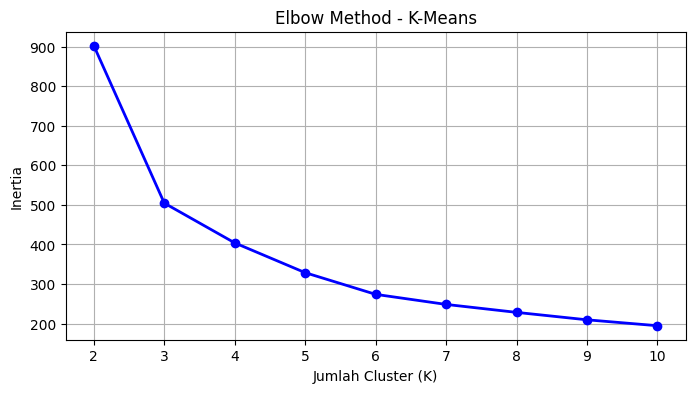

=== K-MEANS CLUSTERING ===
Inertia         : 403.9787
Silhouette Score: 0.4218

Jumlah data per cluster:
cluster
0    1070
1    1065
2    4461
3    1986
Name: count, dtype: int64

✅ Model K-Means berhasil disimpan!


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

# Gunakan fitur numerik untuk clustering
cluster_features = ['track_popularity', 'artist_popularity', 
                    'artist_followers', 'track_duration_min']
X_cluster = df[cluster_features].copy()

# Normalisasi
scaler_kmeans = MinMaxScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(X_cluster)

# Elbow method - cari K terbaik
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - K-Means')
plt.grid(True)
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

# Pakai K=4
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_model.fit_predict(X_cluster_scaled)

# Evaluasi
inertia = kmeans_model.inertia_
silhouette = silhouette_score(X_cluster_scaled, df['cluster'])

print("=== K-MEANS CLUSTERING ===")
print(f"Inertia         : {inertia:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"\nJumlah data per cluster:")
print(df['cluster'].value_counts().sort_index())

# Simpan model
joblib.dump(kmeans_model, 'model_kmeans.pkl')
joblib.dump(scaler_kmeans, 'scaler_kmeans.pkl')
print("\n✅ Model K-Means berhasil disimpan!")


=== BACKPROPAGATION ===
MAE  : 45.6341
RMSE : 50.5929
R²   : -3.3066


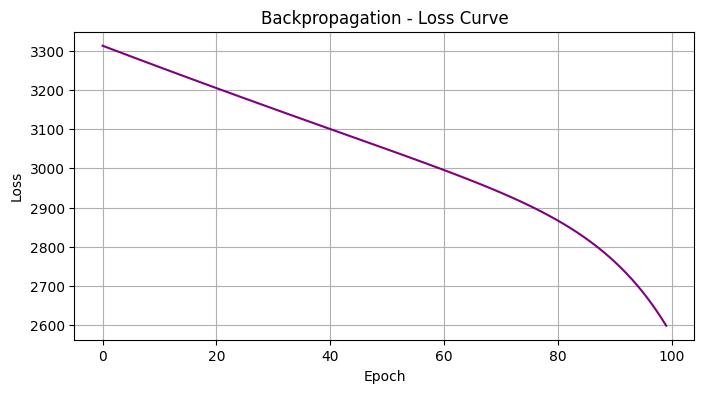


✅ Model Backpropagation berhasil disimpan!


In [12]:
# Backpropagation Manual menggunakan NumPy
class BackpropNetwork:
    def __init__(self, layers):
        self.weights = []
        self.biases = []
        for i in range(len(layers)-1):
            w = np.random.randn(layers[i], layers[i+1]) * 0.01
            b = np.zeros((1, layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        self.activations = [X]
        for i, (w, b) in enumerate(zip(self.weights, self.biases)):
            z = self.activations[-1] @ w + b
            a = self.relu(z) if i < len(self.weights)-1 else z
            self.activations.append(a)
        return self.activations[-1]

    def backward(self, X, y, lr=0.001):
        m = X.shape[0]
        delta = (self.activations[-1] - y.reshape(-1,1)) / m
        for i in range(len(self.weights)-1, -1, -1):
            dw = self.activations[i].T @ delta
            db = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_derivative(self.activations[i])
            self.weights[i] -= lr * dw
            self.biases[i] -= lr * db

    def train(self, X, y, epochs=100, lr=0.001):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X)
            loss = np.mean((output - y.reshape(-1,1))**2)
            losses.append(loss)
            self.backward(X, y, lr)
        return losses

# Train
bp_net = BackpropNetwork([8, 64, 32, 1])
losses = bp_net.train(X_train_scaled, y_train.values, epochs=100, lr=0.001)

# Evaluasi
y_pred_bp = bp_net.forward(X_test_scaled).flatten()
mae_bp = mean_absolute_error(y_test, y_pred_bp)
rmse_bp = np.sqrt(mean_squared_error(y_test, y_pred_bp))
r2_bp = r2_score(y_test, y_pred_bp)

print("=== BACKPROPAGATION ===")
print(f"MAE  : {mae_bp:.4f}")
print(f"RMSE : {rmse_bp:.4f}")
print(f"R²   : {r2_bp:.4f}")

# Plot loss curve
plt.figure(figsize=(8,4))
plt.plot(losses, color='purple')
plt.title('Backpropagation - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('backprop_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan weights
np.save('model_backprop_weights.npy', np.array(bp_net.weights, dtype=object))
print("\n✅ Model Backpropagation berhasil disimpan!")

In [13]:
# Tabel perbandingan semua model
print("=" * 55)
print("       TABEL PERBANDINGAN 5 ALGORITMA ML")
print("=" * 55)
print(f"{'Algoritma':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Linear Regression':<25} {mae_lr:>8.4f} {rmse_lr:>8.4f} {r2_lr:>8.4f}")
print(f"{'ANN':<25} {mae_ann:>8.4f} {rmse_ann:>8.4f} {r2_ann:>8.4f}")
print(f"{'RNN/LSTM':<25} {mae_lstm:>8.4f} {rmse_lstm:>8.4f} {'N/A':>8}")
print(f"{'K-Means':<25} {'N/A':>8} {'N/A':>8} {'N/A':>8}")
print(f"{'Backpropagation':<25} {mae_bp:>8.4f} {rmse_bp:>8.4f} {r2_bp:>8.4f}")
print("=" * 55)
print(f"\n✅ Algoritma terbaik: ANN (MAE terendah: {mae_ann:.4f})")

       TABEL PERBANDINGAN 5 ALGORITMA ML
Algoritma                      MAE     RMSE       R²
-------------------------------------------------------
Linear Regression          15.7135  20.6721   0.2810
ANN                        14.9171  20.1789   0.3149
RNN/LSTM                    1.4745   1.7079      N/A
K-Means                        N/A      N/A      N/A
Backpropagation            45.6341  50.5929  -3.3066

✅ Algoritma terbaik: ANN (MAE terendah: 14.9171)


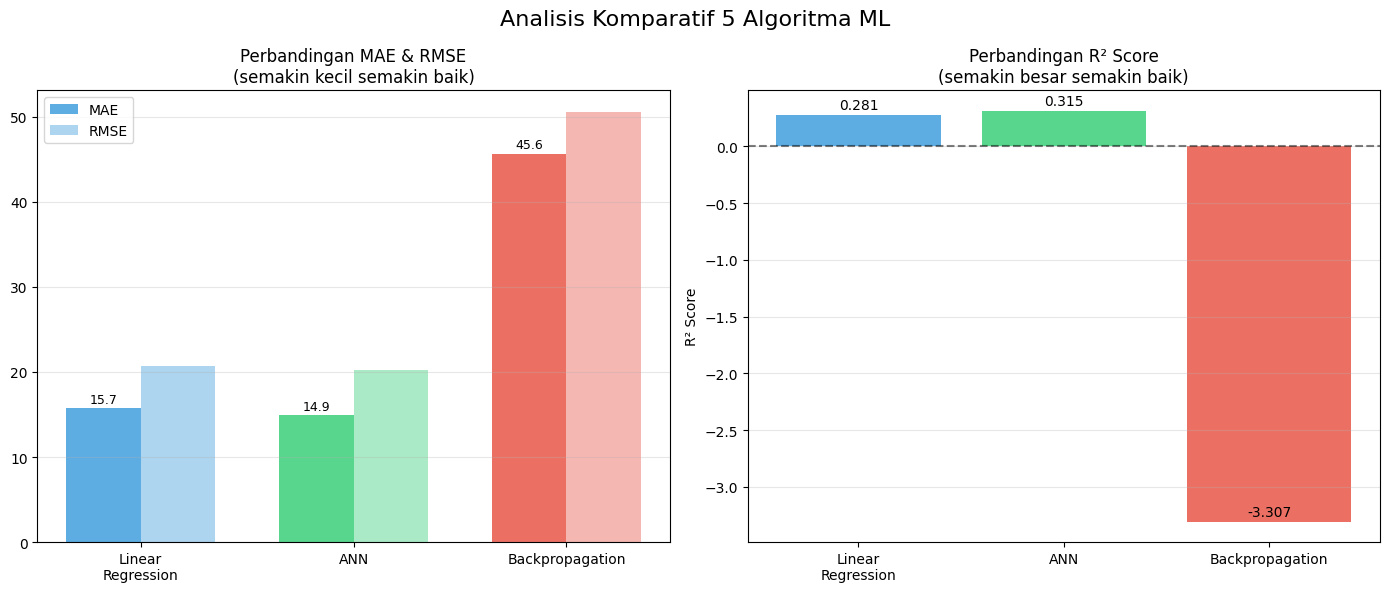

✅ Grafik komparatif berhasil disimpan!


In [14]:
# Visualisasi perbandingan semua model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Komparatif 5 Algoritma ML', fontsize=16)

# Data perbandingan
models = ['Linear\nRegression', 'ANN', 'Backpropagation']
mae_scores = [mae_lr, mae_ann, mae_bp]
rmse_scores = [rmse_lr, rmse_ann, rmse_bp]
r2_scores = [r2_lr, r2_ann, r2_bp]
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Grafik MAE & RMSE
x = np.arange(len(models))
width = 0.35
bars1 = axes[0].bar(x - width/2, mae_scores, width, label='MAE', color=colors, alpha=0.8)
bars2 = axes[0].bar(x + width/2, rmse_scores, width, label='RMSE', 
                     color=colors, alpha=0.4)
axes[0].set_title('Perbandingan MAE & RMSE\n(semakin kecil semakin baik)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# Grafik R²
axes[1].bar(models, r2_scores, color=colors, alpha=0.8)
axes[1].set_title('Perbandingan R² Score\n(semakin besar semakin baik)')
axes[1].set_ylabel('R² Score')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(r2_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('komparatif_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik komparatif berhasil disimpan!")